In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp

# Data Carpentry

In [3]:
Data_PSH_Red = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/PS-H_Red.csv")
Data_PSH_Yellow = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/PS-H_Yellow.csv")
Data_PSH_Green = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/PS-H_Green.csv")
Data_PSH = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/PS-H_Standard.csv")

In [4]:
def ConvertPSH_rv_mp(RvValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    # plt.scatter(x,y)

    coefficients = np.polyfit(x,y,3)
    p = np.poly1d(coefficients)
    xp = np.linspace(np.min(Data_PSH.rv),np.max(Data_PSH.rv),100)
    # plt.scatter(xp,p(xp))
    
    LoggedMpValues = p(RvValues)
    MpValues = np.exp(LoggedMpValues)
    return MpValues

In [5]:
PSHSomeRvValues = np.linspace(0,28,100)
PSHSomeMpValues = ConvertPSH_rv_mp(PSHSomeRvValues)

In [6]:
def AnXAxisCutter(LowerLimit,UpperLimit,Dataframe):
    StartIdx = 0
    EndIdx = len(Dataframe)-1
    LowerLimitIdx = 0
    UpperLimitIdx = 0
    for count,i in enumerate(Dataframe.rv):
        if i > LowerLimit:
            LowerLimitIdx = count
            break
    for count,i in enumerate(Dataframe.rv):
        if i > UpperLimit:
            UpperLimitIdx = count
            break
    FirstDropRange = np.linspace(StartIdx,LowerLimitIdx,(LowerLimitIdx-StartIdx)+1).astype(int).tolist()
    SecondDropRange = np.linspace(UpperLimitIdx,EndIdx,(EndIdx-UpperLimitIdx)+1).astype(int).tolist()
    NewDataframe = Dataframe.drop(FirstDropRange)
    NewestDataframe = NewDataframe.drop(SecondDropRange)
    return NewestDataframe

In [7]:
def RemoveBaseline(Baseline,RawData):
    ProcessedData = []
    for i in RawData:
        j = i-Baseline
        if j < 0:
            ProcessedDatum = 0
            ProcessedData.append(ProcessedDatum)
        else:
            ProcessedDatum = j
            ProcessedData.append(ProcessedDatum)
    return ProcessedData

In [8]:
Data_HMWR_PPSI = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/HMWR_PPSI.csv")
Data_HMWR_PPSI_CutOff = AnXAxisCutter(9.4,20.4,Data_HMWR_PPSI)

In [9]:
Baseline_HMWR_PPSI = 118.52113622417866
Data_HMWR_PPSI_rv = Data_HMWR_PPSI_CutOff.rv
Data_HMWR_PPSI_ri = RemoveBaseline(Baseline_HMWR_PPSI,Data_HMWR_PPSI_CutOff.ri)
Data_HMWR_PPSI_mp = list(ConvertPSH_rv_mp(np.array(Data_HMWR_PPSI_CutOff.rv).tolist()))

In [10]:
Area_PPSI_ri = np.trapz(y=Data_HMWR_PPSI_ri,x=Data_HMWR_PPSI_rv,axis=-1)
Data_HMWR_PPSI_wf = []
Data_HMWR_PPSI_nwf = []
rv_last = 0
ri_last = 0
mw_last = 0
for count,(rv,ri,mw) in enumerate(zip(Data_HMWR_PPSI_rv,Data_HMWR_PPSI_ri,Data_HMWR_PPSI_mp)):
    rv_chng = abs(rv-rv_last)
    ri_chng = ri-ri_last
    if count == 0:
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue
    elif ri_chng<=0:
        area_sq = ri*rv_chng
        area_tri = (rv_chng*abs(ri-ri_last))/2
        area = area_sq-area_tri
        weightfraction = area/Area_PPSI_ri
        Data_HMWR_PPSI_wf.append(weightfraction)
        # mw_logchng = np.log(mw_last)-np.log(mw)
        mw_logchng = abs(np.log(mw)-np.log(mw_last))
        differntialDistribVal = weightfraction/mw_logchng
        Data_HMWR_PPSI_nwf.append(differntialDistribVal)
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue
    else:
        area_sq = ri*rv_chng
        area_tri = (rv_chng*abs(ri-ri_last))/2
        area = area_sq+area_tri
        weightfraction = area/Area_PPSI_ri
        Data_HMWR_PPSI_wf.append(weightfraction)
        # mw_logchng = np.log(mw_last)-np.log(mw)
        mw_logchng = abs(np.log(mw)-np.log(mw_last))
        differntialDistribVal = weightfraction/mw_logchng
        Data_HMWR_PPSI_nwf.append(differntialDistribVal)
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue

In [11]:
rv_last = 0
ri_last = 0
mp_last = 0
new_rv_lis = []
new_ri_lis = []
new_mp_lis = []
for count,(rv,ri,mp) in enumerate(zip(Data_HMWR_PPSI_rv,Data_HMWR_PPSI_ri,Data_HMWR_PPSI_mp)):
    if count == 0:
        rv_last = rv
        ri_last = ri
        mp_last = mp
        continue
    else:
        new_rv_lis.append((rv+rv_last)/2)
        new_ri_lis.append((ri+ri_last)/2)
        new_mp_lis.append((mp+mp_last)/2)
        rv_last = rv
        ri_last = ri
        mp_last = mp
Data_HMWR_PPSI_rv = new_rv_lis
Data_HMWR_PPSI_ri = new_ri_lis
Data_HMWR_PPSI_mp = new_mp_lis

In [12]:
ri = list(reversed(Data_HMWR_PPSI_ri))
mw = list(reversed(Data_HMWR_PPSI_mp))

# Curve A

(0.0, 57.35038380440341)

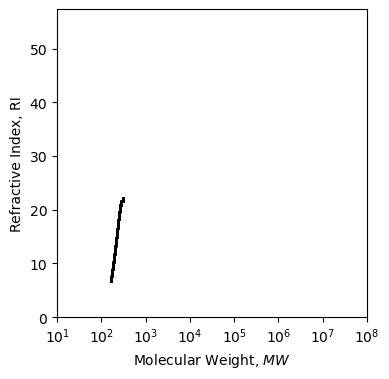

In [13]:
# Curve Isolation
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw[900:1500],ri[900:1500],color="black",s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [14]:
# Curve Model
def f(x,*params):
    a_1,sigma_1,mu_1 = params[0],params[1],params[2]
    return a_1*(1.0/(x*sigma_1*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_1)**2/(2.0*sigma_1**2)))

In [15]:
a_1 = 5.03950566212667
sigma_1 = 0.171895767644522
mu_1 = 5.72589898695787
f_popt,f_pcov = sp.optimize.curve_fit(f=f,xdata=mw[900:1500],ydata=ri[900:1500],p0=[a_1,sigma_1,mu_1])

(0.0, 57.35038380440341)

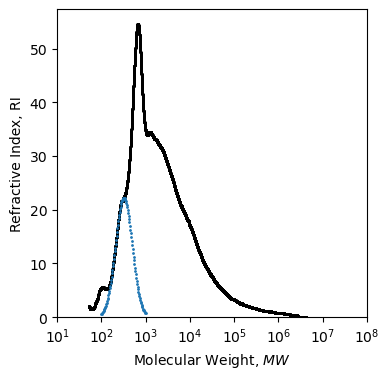

In [16]:
# TrialSamples
fTrialXs = np.logspace(start=2,stop=3,num=100)
fTrialYs = []
for n in fTrialXs:
    fTrialYs.append(f(n,f_popt[0],f_popt[1],f_popt[2]))
# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw,ri,color="black",s=1)
ax1.scatter(fTrialXs,fTrialYs,s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

# Curve B

(0.0, 57.35038380440341)

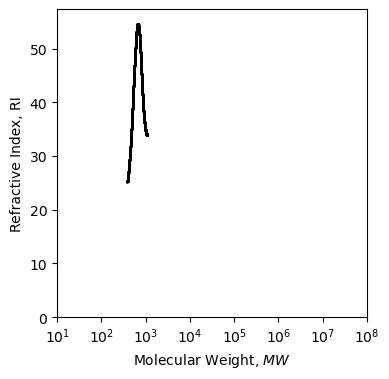

In [17]:
# Curve Isolation
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw[1700:2800],ri[1700:2800],color="black",s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [18]:
# Curve Model
def g(x,*params):
    a_2,sigma_2,mu_2 = params[0],params[1],params[2]
    return a_2*(1.0/(x*sigma_2*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_2)**2/(2.0*sigma_2**2)))

In [19]:
a_2 = 109.978571665277
sigma_2 = 0.230957737603889
mu_2 = 6.53661650427705
g_popt,g_pcov = sp.optimize.curve_fit(f=g,xdata=mw[1700:2800],ydata=ri[1700:2800],p0=[a_2,sigma_2,mu_2])

(0.0, 57.35038380440341)

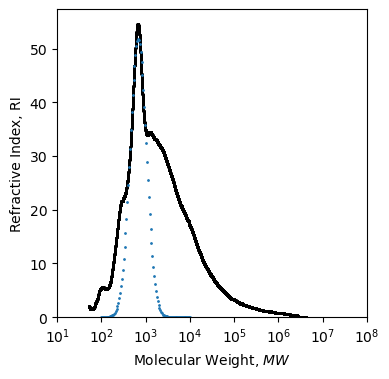

In [20]:
# TrialSamples
gTrialXs = np.logspace(start=2,stop=4,num=100)
gTrialYs = []
for n in gTrialXs:
    gTrialYs.append(g(n,g_popt[0],g_popt[1],g_popt[2]))
# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw,ri,color="black",s=1)
ax1.scatter(gTrialXs,gTrialYs,s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

# Curve C

(0.0, 57.35038380440341)

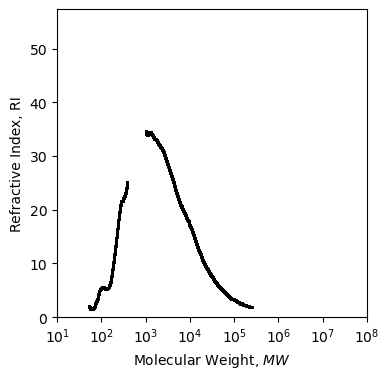

In [21]:
# Curve Isolation
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw[0:1700],ri[0:1700],color="black",s=1)
ax1.scatter(mw[2700:9000],ri[2700:9000],color="black",s=1)
ax1.scatter(mw[0:1700]+mw[2700:9000],ri[0:1700]+ri[2700:9000],color="black",s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [22]:
# Curve Model
def h(x,*params):
    a_3,sigma_3,mu_3 = params[0],params[1],params[2]
    return a_3*(1.0/(x*sigma_3*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_3)**2/(2.0*sigma_3**2)))

In [23]:
# Fitting
a_3 = 9110.46065737538
sigma_3 = 1.50187563742626
mu_3 = 9.87858247573214
h_popt,h_pcov = sp.optimize.curve_fit(f=h,xdata=mw[0:1700]+mw[2700:9000],ydata=ri[0:1700]+ri[2700:9000],p0=[a_3,sigma_3,mu_3])

(0.0, 57.35038380440341)

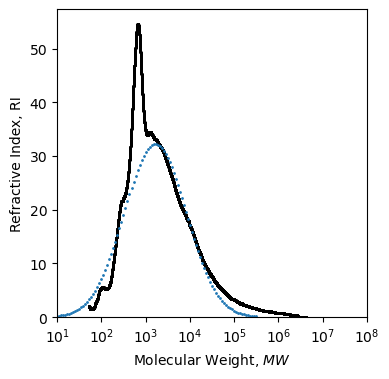

In [24]:
# TrialSamples
hTrialXs = np.logspace(start=1,stop=5.5,num=100)
hTrialYs = []
for n in hTrialXs:
    hTrialYs.append(h(n,h_popt[0],h_popt[1],h_popt[2]))
# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw,ri,color="black",s=1)
ax1.scatter(hTrialXs,hTrialYs,s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

# Curves A, B, & C

(0.0, 57.35038380440341)

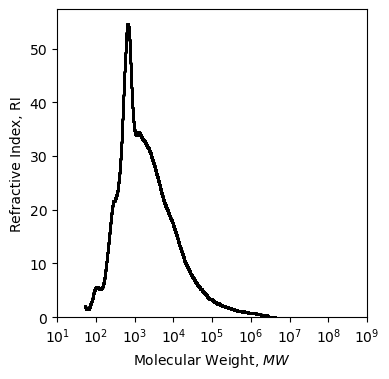

In [25]:
# Curve Isolation
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.scatter(mw[0:11000],ri[0:11000],color="black",s=1)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,1000000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000,1000000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [26]:
def i(x,*params):
    a = f(x,params[0],params[1],params[2])
    b = g(x,params[3],params[4],params[5])
    c = h(x,params[6],params[7],params[8])
    return a+b+c

In [27]:
a_1 = f_popt[0]
sigma_1 = f_popt[1]
mu_1 = f_popt[2]

a_2 = g_popt[0]
sigma_2 = g_popt[1]
mu_2 = g_popt[2]

a_3 = h_popt[0]
sigma_3 = h_popt[1]
mu_3 = h_popt[2]

i_popt,i_pcov = sp.optimize.curve_fit(f=i,xdata=mw[0:11000],ydata=ri[0:11000],p0=[a_1,sigma_1,mu_1,a_2,sigma_2,mu_2,a_3,sigma_3,mu_3],maxfev=2000)

(0.0, 57.35038380440341)

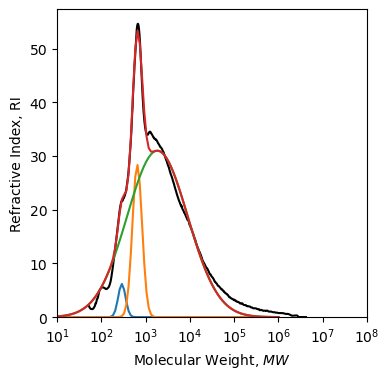

In [28]:
# TrialSamples
FinalTrialXs = np.logspace(start=1,stop=6,num=100)

FinalfTrialYs = []
for n in FinalTrialXs:
    FinalfTrialYs.append(f(n,i_popt[0],i_popt[1],i_popt[2]))

FinalgTrialYs = []
for n in FinalTrialXs:
    FinalgTrialYs.append(g(n,i_popt[3],i_popt[4],i_popt[5]))

FinalhTrialYs = []
for n in FinalTrialXs:
    FinalhTrialYs.append(h(n,i_popt[6],i_popt[7],i_popt[8]))

FinaliTrialYs = []
for n in FinalTrialXs:
    FinaliTrialYs.append(i(n,i_popt[0],i_popt[1],i_popt[2],i_popt[3],i_popt[4],i_popt[5],i_popt[6],i_popt[7],i_popt[8]))

# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.plot(mw,ri,color="black")
ax1.plot(FinalTrialXs,FinalfTrialYs)
ax1.plot(FinalTrialXs,FinalgTrialYs)
ax1.plot(FinalTrialXs,FinalhTrialYs)
ax1.plot(FinalTrialXs,FinaliTrialYs)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,100000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [29]:
# Fitted Distribution - A
AreaA = np.trapz(x=FinalTrialXs,y=FinalfTrialYs,dx=0.01)
# Fitted Distribution - B
AreaB = np.trapz(x=FinalTrialXs,y=FinalgTrialYs,dx=0.01)
# Fitted Distribution - C
AreaC = np.trapz(x=FinalTrialXs,y=FinalhTrialYs,dx=0.01)
# Combined Distribution - D
AreaD = np.trapz(x=FinalTrialXs,y=FinaliTrialYs,dx=0.01)

In [30]:
print(round(AreaA/AreaD*100,2))
print(round(AreaB/AreaD*100,2))
print(round(AreaC/AreaD*100,2))
print(round(AreaD/AreaD*100,2))

0.11
1.53
98.36
100.0


# Pulling Further Insights

In [31]:
def MolecularWeightFinder(RelativeIntensityData,RetentionVolumeData,MolecularMassData,IterativeSteps):
    MaximumRetentionVolume = np.max(RetentionVolumeData)
    MinimumRetentionVolume = np.min(RetentionVolumeData)
    RetentionVolumeRange = MaximumRetentionVolume-MinimumRetentionVolume
    VolumePerStep = RetentionVolumeRange/IterativeSteps

    IterativelyProducedAverages_ri = []
    IterativelyProducedAverages_mp = []
    CurrentVolume = MinimumRetentionVolume
    for step in range(IterativeSteps):
        if step+1 == IterativeSteps:
            LowerVolumeLimit = CurrentVolume
            UpperVolumeLimit = CurrentVolume+VolumePerStep

            LowerVolumeLimitIdx = 0
            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > LowerVolumeLimit:
                    LowerVolumeLimitIdx = count
                    break

            UpperVolumeLimitIdx = len(RetentionVolumeData)-1

            VolumeIdxRange = np.linspace(LowerVolumeLimitIdx,UpperVolumeLimitIdx,(UpperVolumeLimitIdx-LowerVolumeLimitIdx)+1).astype('int').tolist()
            
            Filtered_ri = np.array(RelativeIntensityData)[VolumeIdxRange]
            Filtered_mp = np.array(MolecularMassData)[VolumeIdxRange]

            ri_avg = np.average(Filtered_ri)
            mp_avg = np.average(Filtered_mp)

            IterativelyProducedAverages_ri.append(ri_avg)
            IterativelyProducedAverages_mp.append(mp_avg)
            break
        else:
            LowerVolumeLimit = CurrentVolume
            UpperVolumeLimit = CurrentVolume+VolumePerStep

            LowerVolumeLimitIdx = 0
            UpperVolumeLimitIdx = 0

            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > LowerVolumeLimit:
                    LowerVolumeLimitIdx = count
                    break
                
            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > UpperVolumeLimit:
                    UpperVolumeLimitIdx = count
                    break

            VolumeIdxRange = np.linspace(LowerVolumeLimitIdx,UpperVolumeLimitIdx,(UpperVolumeLimitIdx-LowerVolumeLimitIdx)+1).astype('int').tolist()
            
            Filtered_ri = np.array(RelativeIntensityData)[VolumeIdxRange]
            Filtered_mp = np.array(MolecularMassData)[VolumeIdxRange]

            ri_avg = np.average(Filtered_ri)
            mp_avg = np.average(Filtered_mp)

            IterativelyProducedAverages_ri.append(ri_avg)
            IterativelyProducedAverages_mp.append(mp_avg)

            CurrentVolume = UpperVolumeLimit
            continue

    # Number Average Molecular Weight
    a = np.sum(IterativelyProducedAverages_ri)
    b = np.array(IterativelyProducedAverages_ri)
    c = np.array(IterativelyProducedAverages_mp)
    d = b/c
    e = np.sum(d)
    f = a/e

    # Weight Average Molecular Weight
    g = b*c
    h = np.sum(g)
    i = h/a

    # Dispersity
    j = i/f

    return f,i,j # number average, weight average, dispersity

In [37]:
def ConvertPSH_mp_rv(MpValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    coefficients = np.polyfit(y,x,3)
    p = np.poly1d(coefficients)
    LoggedRvValues = p(np.log(MpValues))
    RvValues = LoggedRvValues
    return RvValues

In [47]:
IterativeSteps = 1000
A_NumAveMolWei,A_WeiAveMolWei,A_Disp = MolecularWeightFinder(FinalfTrialYs,list(reversed(ConvertPSH_mp_rv(FinalTrialXs).tolist())),FinalTrialXs,IterativeSteps)
B_NumAveMolWei,B_WeiAveMolWei,B_Disp = MolecularWeightFinder(FinalgTrialYs,list(reversed(ConvertPSH_mp_rv(FinalTrialXs).tolist())),FinalTrialXs,IterativeSteps)
C_NumAveMolWei,C_WeiAveMolWei,C_Disp = MolecularWeightFinder(FinalhTrialYs,list(reversed(ConvertPSH_mp_rv(FinalTrialXs).tolist())),FinalTrialXs,IterativeSteps)
D_NumAveMolWei,D_WeiAveMolWei,D_Disp = MolecularWeightFinder(FinaliTrialYs,list(reversed(ConvertPSH_mp_rv(FinalTrialXs).tolist())),FinalTrialXs,IterativeSteps)

In [48]:
print(A_NumAveMolWei)
print(B_NumAveMolWei)
print(C_NumAveMolWei)
print(D_NumAveMolWei)

286.5517357267075
629.1652260843433
605.4988812023294
594.7359380526732


In [49]:
print(A_WeiAveMolWei)
print(B_WeiAveMolWei)
print(C_WeiAveMolWei)
print(D_WeiAveMolWei)

297.0567078893832
670.5139366770044
5545.332469152414
4808.558974733748


In [50]:
print(A_Disp)
print(B_Disp)
print(C_Disp)
print(D_Disp)

1.036659949506272
1.0657199553923185
9.158286895825698
8.085199946850823
